In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
np.random.seed(42)

crop_conditions = {
    "Rice":      [80, 45, 40, 27, 82, 6.2, 220],
    "Maize":     [75, 50, 45, 25, 65, 6.5, 100],
    "Wheat":     [55, 35, 40, 20, 55, 6.5, 70],
    "Cotton":    [100, 45, 50, 28, 60, 6.0, 90],
    "Sugarcane": [90, 45, 55, 28, 75, 6.5, 180],
    "Potato":    [50, 45, 50, 19, 70, 5.8, 80],
    "Tomato":    [60, 40, 45, 24, 65, 6.0, 100],
    "Groundnut": [40, 30, 35, 27, 60, 6.3, 70],
    "Banana":    [100, 75, 50, 28, 80, 6.2, 200],
    "Mango":     [25, 30, 25, 27, 55, 6.5, 90]
}

data = []

for crop, values in crop_conditions.items():

    N, P, K, temperature, humidity, ph, rainfall = values

    for i in range(100):

        data.append([
            np.random.normal(N, 8),
            np.random.normal(P, 6),
            np.random.normal(K, 6),
            np.random.normal(temperature, 2),
            np.random.normal(humidity, 5),
            np.random.normal(ph, 0.3),
            np.random.normal(rainfall, 20),
            crop
        ])

columns = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall",
    "label"
]

df = pd.DataFrame(data, columns=columns)

print("Dataset created successfully!")
print("Dataset shape:", df.shape)

display(df.head(10))

Dataset created successfully!
Dataset shape: (1000, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,83.973713,44.170414,43.886131,30.046060,80.829233,6.129759,251.584256,Rice
1,86.139478,42.183154,43.255360,26.073165,79.671351,6.272589,181.734395,Rice
2,66.200657,41.626275,33.923013,27.628495,77.459880,5.776309,249.312975,Rice
3,78.193790,45.405169,31.451511,25.911235,82.554613,5.854702,227.513960,Rice
4,75.194890,43.249838,36.389760,30.704556,81.932514,5.882687,236.450898,Rice
5,70.233251,46.253182,28.241979,24.343628,82.984306,6.421540,223.427366,Rice
6,79.074814,43.193378,31.128868,25.560312,79.696806,6.517137,226.872366,Rice
7,65.895679,46.944504,37.689506,25.646156,85.058381,6.509300,238.625602,Rice
8,73.286260,43.144726,41.987581,28.951090,79.604129,6.144302,197.873301,Rice
9,70.430347,49.875155,48.137440,26.855980,87.017664,6.308491,207.097605,Rice


In [ ]:
print("Column Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCrop Distribution:")
print(df["label"].value_counts())

Column Names:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Crop Distribution:
label
Rice         100
Maize        100
Wheat        100
Cotton       100
Sugarcane    100
Potato       100
Tomato       100
Groundnut    100
Banana       100
Mango        100
Name: count, dtype: int64


In [ ]:
features = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

X = df[features]
y = df["label"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,N,P,K,temperature,humidity,ph,rainfall
0,83.973713,44.170414,43.886131,30.046060,80.829233,6.129759,251.584256
1,86.139478,42.183154,43.255360,26.073165,79.671351,6.272589,181.734395
2,66.200657,41.626275,33.923013,27.628495,77.459880,5.776309,249.312975
3,78.193790,45.405169,31.451511,25.911235,82.554613,5.854702,227.513960
4,75.194890,43.249838,36.389760,30.704556,81.932514,5.882687,236.450898



Target:


,label
0,Rice
1,Rice
2,Rice
3,Rice
4,Rice


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [ ]:
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("===================================")
print("       MODEL PERFORMANCE")
print("===================================")

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

       MODEL PERFORMANCE
Accuracy: 91.0 %

Classification Report:
              precision    recall  f1-score   support

      Banana       0.95      0.95      0.95        20
      Cotton       0.95      1.00      0.98        20
   Groundnut       0.83      0.95      0.88        20
       Maize       0.85      0.85      0.85        20
       Mango       0.94      0.85      0.89        20
      Potato       0.95      0.90      0.92        20
        Rice       1.00      0.95      0.97        20
   Sugarcane       0.90      0.90      0.90        20
      Tomato       0.76      0.80      0.78        20
       Wheat       1.00      0.95      0.97        20

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



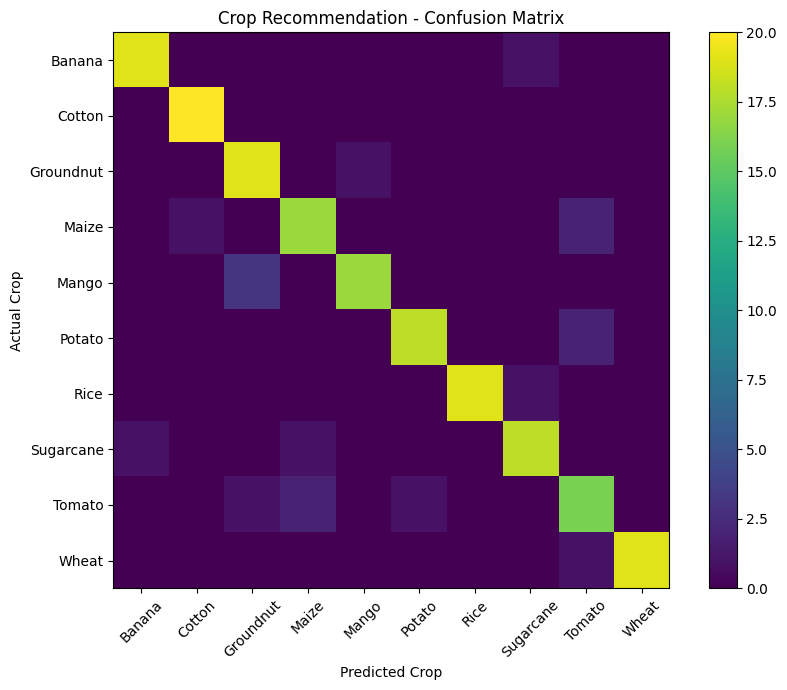

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title("Crop Recommendation - Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.xticks(
    range(len(model.classes_)),
    model.classes_,
    rotation=45
)

plt.yticks(
    range(len(model.classes_)),
    model.classes_
)

plt.colorbar()

plt.tight_layout()
plt.show()

Feature Importance:


,Feature,Importance
0,N,0.237882
1,P,0.162263
6,rainfall,0.154078
3,temperature,0.129676
4,humidity,0.117516
2,K,0.114357
5,ph,0.084228


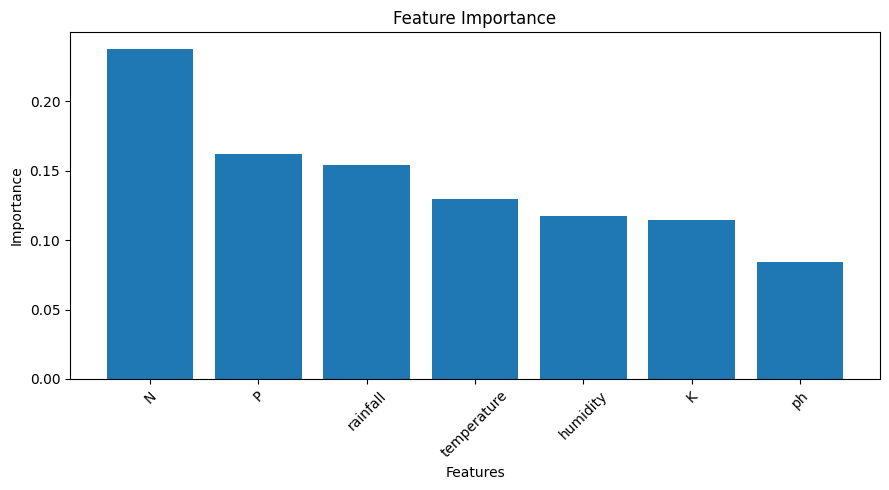

In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(importance)

plt.figure(figsize=(9, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================
# CELL 10 - WEATHER & SOIL INPUT
# ==============================================================

# Enter the values you want to test here

N = 80
P = 45
K = 40

temperature = 27
humidity = 82
ph = 6.2
rainfall = 220


# Create input dataframe

input_data = pd.DataFrame({
    "N": [N],
    "P": [P],
    "K": [K],
    "temperature": [temperature],
    "humidity": [humidity],
    "ph": [ph],
    "rainfall": [rainfall]
})

print("==========================================")
print("       WEATHER & SOIL INPUT")
print("==========================================")

display(input_data)

print("Input data prepared successfully!")

       WEATHER & SOIL INPUT


,N,P,K,temperature,humidity,ph,rainfall
0,80,45,40,27,82,6.2,220


Input data prepared successfully!


In [ ]:
# ==============================================================
# CELL 11 - CROP RECOMMENDATION
# ==============================================================

prediction = model.predict(input_data)

recommended_crop = prediction[0]

print("==========================================")
print("          CROP RECOMMENDATION")
print("==========================================")

print("Recommended Crop:", recommended_crop)

          CROP RECOMMENDATION
Recommended Crop: Rice


In [ ]:
# ==============================================================
# CELL 12 - TOP 5 CROP RECOMMENDATIONS
# ==============================================================

probability = model.predict_proba(input_data)[0]

recommendations = pd.DataFrame({
    "Crop": model.classes_,
    "Probability (%)": probability * 100
})

recommendations = recommendations.sort_values(
    by="Probability (%)",
    ascending=False
)

recommendations["Probability (%)"] = recommendations[
    "Probability (%)"
].round(2)

print("==========================================")
print("        TOP 5 CROP RECOMMENDATIONS")
print("==========================================")

display(recommendations.head(5))

        TOP 5 CROP RECOMMENDATIONS


,Crop,Probability (%)
6,Rice,98.67
3,Maize,0.67
7,Sugarcane,0.67
0,Banana,0.00
1,Cotton,0.00


In [2]:
# ==============================================================
# LIVE DEMO - WEATHER BASED CROPS RECOMMENDATION USING ML
# ==============================================================

!pip -q install gradio

import gradio as gr

def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):

    input_data = pd.DataFrame([[
        N, P, K, temperature, humidity, ph, rainfall
    ]], columns=features)

    # Predict crop
    prediction = model.predict(input_data)[0]

    # Prediction probabilities
    probabilities = model.predict_proba(input_data)[0]

    result = pd.DataFrame({
        "Crop": model.classes_,
        "Probability (%)": probabilities * 100
    })

    result = result.sort_values(
        by="Probability (%)",
        ascending=False
    ).head(5)

    result["Probability (%)"] = result[
        "Probability (%)"
    ].round(2)

    return prediction, result


# Create Live Demo Interface

demo = gr.Interface(
    fn=recommend_crop,

    inputs=[
        gr.Slider(0, 140, value=80, step=1,
                  label="Nitrogen (N)"),

        gr.Slider(0, 100, value=45, step=1,
                  label="Phosphorus (P)"),

        gr.Slider(0, 100, value=40, step=1,
                  label="Potassium (K)"),

        gr.Slider(10, 40, value=27, step=0.1,
                  label="Temperature (°C)"),

        gr.Slider(20, 100, value=82, step=1,
                  label="Humidity (%)"),

        gr.Slider(4, 9, value=6.2, step=0.1,
                  label="Soil pH"),

        gr.Slider(20, 300, value=220, step=1,
                  label="Rainfall (mm)")
    ],

    outputs=[
        gr.Textbox(label="🌱 Recommended Crop"),
        gr.Dataframe(label="Top 5 Crop Recommendations")
    ],

    title="🌾 Weather Based Crops Recommendation Using ML",

    description=(
        "Enter the soil and weather conditions below "
        "to get a suitable crop recommendation."
    )
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8003832b1b9335fea1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
